# B4T1 - Diseño de Redes Confiables
## Parte 1: Arquitectura Customizada + Modelo Base

## 1. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

## 2. Carga y preprocesado de datos

In [13]:
def load_home_credit_data(file_path):
    cols = [
        'TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
    ]

    df = pd.read_csv(file_path, usecols=cols)

    # Eliminar filas con género desconocido
    df = df[df['CODE_GENDER'].isin(['M', 'F'])]

    # Género a numérico (variable sensible): M=0, F=1
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})

    # Edad a años positivos
    df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

    # Imputar nulos de EXT_SOURCE con la mediana y crear columnas indicadoras de nulos
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        df[col + '_NULL'] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(df[col].median())

    # Imputar AMT_ANNUITY
    df['AMT_ANNUITY'] = df['AMT_ANNUITY'].fillna(df['AMT_ANNUITY'].median())

    # Separar X, y, s
    X = df.drop(columns=['TARGET'])
    y = df['TARGET']
    s = df['CODE_GENDER']

    # Split train/test
    X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
        X, y, s, test_size=0.2, random_state=42, stratify=y
    )

    # Escalado
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return (X_train, y_train, s_train), (X_test, y_test, s_test)

In [14]:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data('data/application_train.csv')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Tasa de impago: {y_train.mean():.3f}")

X_train: (246005, 11)
X_test:  (61502, 11)
Tasa de impago: 0.081


## 3. Análisis exploratorio (EDA)

In [15]:
df_raw = pd.read_csv('data/application_train.csv')

# Nulos en las columnas que usamos
cols_interes = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_ANNUITY']
nulos = df_raw[cols_interes].isnull().sum()
porcentaje = (nulos / len(df_raw) * 100).round(2)

pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})

,Nulos,Porcentaje (%)
EXT_SOURCE_1,173378,56.38
EXT_SOURCE_2,660,0.21
EXT_SOURCE_3,60965,19.83
AMT_ANNUITY,12,0.00


Tasa de impago: 8.07%


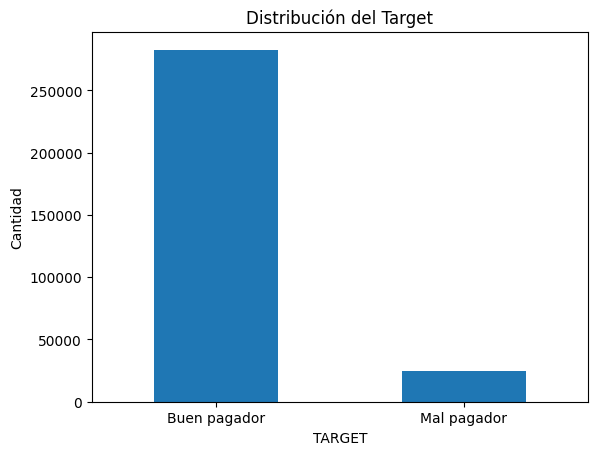

In [16]:
# Distribución del target
target_counts = df_raw['TARGET'].value_counts()
porcentaje_impago = df_raw['TARGET'].mean() * 100

print(f"Tasa de impago: {porcentaje_impago:.2f}%")
target_counts.plot(kind='bar')
plt.title('Distribución del Target')
plt.xticks([0, 1], ['Buen pagador', 'Mal pagador'], rotation=0)
plt.ylabel('Cantidad')
plt.show()

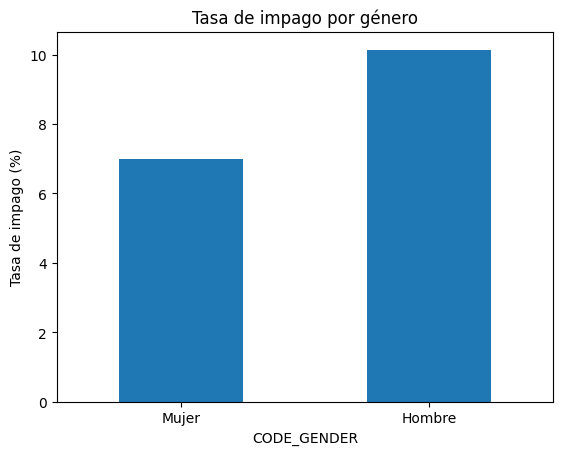

In [17]:
# Tasa de impago por género
impago_genero = df_raw[df_raw['CODE_GENDER'].isin(['M', 'F'])].groupby('CODE_GENDER')['TARGET'].mean() * 100

impago_genero.plot(kind='bar')
plt.title('Tasa de impago por género')
plt.xticks([0, 1], ['Mujer', 'Hombre'], rotation=0)
plt.ylabel('Tasa de impago (%)')
plt.show()

### Conclusiones del EDA
- El dataset está muy desbalanceado: solo el 8% son malos pagadores. 
Se deberá compensar durante el entrenamiento dando más peso a la clase positiva.
- EXT_SOURCE_1 tiene un 56% de nulos y EXT_SOURCE_3 un 20%. 
Se imputan con la mediana y se añade un flag por columna para que la red sepa dónde faltaba información.
- Existe una diferencia real en la tasa de impago por género (hombres ~10% vs mujeres ~7%), 
lo que justifica la necesidad de una FAIR loss para evitar discriminación.